In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os
import time
import warnings
from KalmanFilter import KalmanFilter as KF_Class
from Helpers_KF import initConstAccelerationKF, initConstVelocityKF

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

# Path dataset
TEST_DATA_FILE_PATH_DL = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL_full.csv'
TEST_DATA_FILE_PATH_SCANNER = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.csv'
TEST_DATA_FILE_PATH_UL = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/UL_fill.csv'

sheet_name_test = "Series_Formatted_Data"

# Direktori model
MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated"
SAVED_MODEL_BASE_NAMES = [
    os.path.join(MODEL_DIR_LGBM, "DL_w_pathloss_nbr0"),
    os.path.join(MODEL_DIR_LGBM, "UL_fill_w_pathloss_nbr0"),
    os.path.join(MODEL_DIR_LGBM, "Scanner_fill_w_pathloss_nbr0")
]

# Fitur untuk masing-masing dataset
FEATURE_COLS_DL = [
    'NR_UE_Pathloss_DL_0',
    'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0'
]

FEATURE_COLS_UL = [
    'NR_UE_Pathloss_DL_0',
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0'
]

FEATURE_COLS_SCANNER = [
'NR_Scan_PCI_SortedBy_RSRP_0',
'NR_Scan_PCI_SortedBy_RSRP_1',
'NR_Scan_PCI_SortedBy_RSRP_2',
'NR_Scan_PCI_SortedBy_RSRP_3',
'NR_Scan_PCI_SortedBy_RSRP_4',
'NR_Scan_PCI_SortedBy_RSRP_5',
'NR_Scan_PCI_SortedBy_RSRP_6',


'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
'NR_Scan_SSB_SINR_SortedBy_RSRP_3',
'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
'NR_Scan_SSB_SINR_SortedBy_RSRP_6',

]

TARGET_COLS = ['Latitude', 'Longitude']
MODEL_WAS_TRAINED_WITH_SCALING = False
KF_DELTA_T = 1.0  # Interval resampling (detik)
RESULTS_DIR_TESTING = 'results_lgbm_kf_downsampled_testing'
os.makedirs(RESULTS_DIR_TESTING, exist_ok=True)

# --- Fungsi Bantuan --- #

def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def load_trained_lgbm_models_and_scalers(model_paths, model_was_scaled):
    models, scalers = [], []
    for path in model_paths:
        model_path = f"{path}_lgbm.joblib"
        scaler_path = f"{path}_scaler.joblib"
        model = joblib.load(model_path)
        print(f"Model loaded from: {model_path}")
        models.append(model)
        if model_was_scaled:
            try:
                scaler = joblib.load(scaler_path)
                print(f"Scaler loaded from: {scaler_path}")
                scalers.append(scaler)
            except Exception as e:
                print(f"Scaler not found for {model_path}: {e}")
                scalers.append(None)
        else:
            scalers.append(None)
    return models, scalers

def prepare_test_data(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude'], sheet_n=None):
    print(f"Memuat data test dari {filepath} (Sheet: {sheet_n})...")
    try:
        if filepath.endswith('.xlsx'): df = pd.read_excel(filepath, sheet_name=sheet_n)
        elif filepath.endswith('.csv'): df = pd.read_csv(filepath, low_memory=False)
        else: raise ValueError("Format file tidak didukung")
    except Exception as e:
        print(f"Error membaca file: {e}")
        return None
    df.columns = df.columns.str.strip()
    required_cols = feature_cols_config + target_cols_config + ['Time']
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f"Kolom hilang: {missing_cols}")
        return None
    df_subset = df[required_cols].copy()
    df_subset['Time'] = pd.to_datetime(df_subset['Time'])
    df_subset = df_subset.sort_values('Time').reset_index(drop=True)
    for col in feature_cols_config:
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
    return df_subset

def calculate_error_metrics(y_true, y_pred):
    errors = []
    for (true_lat, true_lon), (pred_lat, pred_lon) in zip(y_true, y_pred):
        if pd.isna([true_lat, true_lon, pred_lat, pred_lon]).any():
            continue
        errors.append(haversine(true_lat, true_lon, pred_lat, pred_lon))
    return np.array(errors)

def plot_cdf(errors_dict, save_path=None):
    plt.figure(figsize=(10, 6))
    for i, (name, errs) in enumerate(errors_dict.items()):
        sorted_errs = np.sort(errs)
        cum_prob = np.arange(1, len(sorted_errs)+1)/len(sorted_errs)
        plt.plot(sorted_errs, cum_prob*100, label=name)
    plt.xlabel("Error (meters)"), plt.ylabel("CDF (%)")
    plt.legend(), plt.grid(True), plt.title("Cumulative Distribution of Errors")
    if save_path: plt.savefig(save_path)
    plt.show()

def plot_map(results_df):
    plt.figure(figsize=(10, 8))
    plt.plot(results_df['true_lon'], results_df['true_lat'], 'b-o', label='True')
    plt.plot(results_df['kf_pred_lon'], results_df['kf_pred_lat'], 'g-o', label='KF')
    for i in range(3):
        plt.plot(results_df[f'pred_lon_model{i}'], results_df[f'pred_lat_model{i}'], 'x--', label=f'Model {i+1}')
    plt.legend(), plt.grid(True), plt.axis('equal'), plt.title("KF vs Model Predictions")
    plt.show()

# --- Main Script --- #
from functools import reduce # Import the reduce function for elegant merging
# --- Main Script (Revised for Large Data with Chunking) --- #
from functools import reduce
import gc # Import the garbage collector

if __name__ == '__main__':
    print("Memulai skrip pengujian dengan Kalman Filter dan 3 model")

    # 1. Muat 3 model LightGBM (this is fine, models are small)
    models, scalers = load_trained_lgbm_models_and_scalers(SAVED_MODEL_BASE_NAMES, MODEL_WAS_TRAINED_WITH_SCALING)
    
    # --- START OF REVISED LOGIC ---

    # Define paths and feature sets for easy iteration
    data_sources = {
        'model0': {
            'path': TEST_DATA_FILE_PATH_DL,
            'features': FEATURE_COLS_DL,
            'model': models[0],
            'scaler': scalers[0]
        },
        'model1': {
            'path': TEST_DATA_FILE_PATH_UL,
            'features': FEATURE_COLS_UL,
            'model': models[1],
            'scaler': scalers[1]
        },
        'model2': {
            'path': TEST_DATA_FILE_PATH_SCANNER,
            'features': FEATURE_COLS_SCANNER,
            'model': models[2],
            'scaler': scalers[2]
        }
    }

    # Define chunk size - you can tune this based on your RAM. 500,000 is a safe start.
    CHUNKSIZE = 500_000
    
    # Use iterators to read CSV files in chunks
    iterators = {}
    for name, source in data_sources.items():
        print(f"Membuka iterator untuk {source['path']}...")
        required_cols = source['features'] + TARGET_COLS + ['Time']
        iterators[name] = pd.read_csv(
            source['path'],
            usecols=required_cols,
            chunksize=CHUNKSIZE,
            parse_dates=['Time'],
            low_memory=True # Use low_memory=True for chunking
        )
    
    # Initialize Kalman Filter
    A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
    kf = KF_Class(A=A_kf, B=B_kf, H=H_kf, Q=Q_kf, R=R_kf, P=P_0_kf, x_0=x_0_kf, obj_id=1)
    
    results_list = []
    is_kf_initialized = False
    
    print(f"\nMemulai pemrosesan data dalam chunk sebesar {CHUNKSIZE} baris...")
    
    # Loop indefinitely, processing one chunk from each file at a time
    while True:
        try:
            # 1. Read one chunk from each file
            chunks = {name: next(it) for name, it in iterators.items()}
            print(f"Memproses chunk berikutnya...")

            # 2. Perform predictions for each chunk and create DataFrames
            pred_dfs = []
            for name, chunk in chunks.items():
                source = data_sources[name]
                
                # Pre-processing within the chunk
                for col in source['features']:
                    chunk[col] = pd.to_numeric(chunk[col], errors='coerce')
                
                # Prediction
                X_chunk = chunk[source['features']]
                pred = source['model'].predict(source['scaler'].transform(X_chunk) if source['scaler'] else X_chunk)
                
                pred_df = pd.DataFrame({
                    'Time': chunk['Time'],
                    f'pred_lat_{name}': pred[:, 0],
                    f'pred_lon_{name}': pred[:, 1],
                })
                # Add ground truth only from the primary source (DL)
                if name == 'model0':
                    pred_df['true_lat'] = chunk['Latitude']
                    pred_df['true_lon'] = chunk['Longitude']

                pred_dfs.append(pred_df)

            # 3. Merge the prediction DataFrames for the current chunk
            df_merged_chunk = reduce(lambda left, right: pd.merge(left, right, on='Time', how='inner'), pred_dfs)

            if df_merged_chunk.empty:
                print("  Chunk tidak memiliki timestamp yang cocok. Melanjutkan ke chunk berikutnya.")
                continue

            # 4. Resample and run Kalman Filter on the merged chunk
            df_resampled = df_merged_chunk.set_index('Time').resample(f'{KF_DELTA_T}S').mean().dropna().reset_index()

            if df_resampled.empty:
                continue
                
            # Initialize KF with the very first valid measurement
            if not is_kf_initialized and not df_resampled.empty:
                first_row = df_resampled.iloc[0]
                initial_lon = (first_row['pred_lon_model0'] + first_row['pred_lon_model1'] + first_row['pred_lon_model2']) / 3
                initial_lat = (first_row['pred_lat_model0'] + first_row['pred_lat_model1'] + first_row['pred_lat_model2']) / 3
                kf.x[0] = initial_lon
                kf.x[1] = initial_lat
                is_kf_initialized = True
                print("Kalman Filter diinisialisasi.")
                
            kf_preds_lat, kf_preds_lon = [], []
            for _, row in df_resampled.iterrows():
                z = np.array([row['pred_lon_model0'], row['pred_lat_model0'],
                              row['pred_lon_model1'], row['pred_lat_model1'],
                              row['pred_lon_model2'], row['pred_lat_model2']])
                kf.performKalmanFilter(z, u=0)
                kf_preds_lon.append(kf.x[0, 0])
                kf_preds_lat.append(kf.x[1, 0])

            df_resampled['kf_pred_lat'] = kf_preds_lat
            df_resampled['kf_pred_lon'] = kf_preds_lon

            # Append the processed, smaller dataframe to our results list
            results_list.append(df_resampled)
            
            # Clean up memory
            del chunks, pred_dfs, df_merged_chunk, df_resampled
            gc.collect()

        except StopIteration:
            # This error means one of the iterators is empty. We're done.
            print("\nSelesai memproses semua chunk.")
            break

    # Concatenate all the small, processed results into one final DataFrame
    print("Menggabungkan semua hasil chunk yang telah diproses...")
    df_final_results = pd.concat(results_list, ignore_index=True)

    # Now proceed with evaluation on the final (and much smaller) results
    print("Mengevaluasi hasil akhir...")
    errors = {}
    y_true_final = df_final_results[['true_lat', 'true_lon']].values

    for i in range(3):
        y_pred_model = df_final_results[[f'pred_lat_model{i}', f'pred_lon_model{i}']].values
        errors[f'Model {i+1}'] = calculate_error_metrics(y_true_final, y_pred_model)
    
    y_pred_kf = df_final_results[['kf_pred_lat', 'kf_pred_lon']].values
    errors['KF'] = calculate_error_metrics(y_true_final, y_pred_kf)

    # Plot hasil
    plot_cdf(errors, os.path.join(RESULTS_DIR_TESTING, "error_cdf.png"))
    plot_map(df_final_results)

    print("Skrip selesai.")

Memulai skrip pengujian dengan Kalman Filter dan 3 model
Model loaded from: trained_models_lightgbm_aggregated\DL_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\UL_fill_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\Scanner_fill_w_pathloss_nbr0_lgbm.joblib
Membuka iterator untuk D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL_full.csv...
Membuka iterator untuk D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/UL_fill.csv...
Membuka iterator untuk D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.csv...

Memulai pemrosesan data dalam chunk sebesar 500000 baris...
Memproses chunk berikutnya...


: 

In [2]:
# --- Main Script (Revised for Real-Time Simulation) ---

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os
import time
import warnings
from functools import reduce
import gc

# Your existing class/function imports
# from KalmanFilter import KalmanFilter as KF_Class
# from Helpers_KF import initConstVelocityKF_for_3_models_2D # Use the correct helper!

from KalmanFilter import KalmanFilter as KF_Class
from Helpers_KF import initConstAccelerationKF, initConstVelocityKF

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

# Path dataset
TEST_DATA_FILE_PATH_DL = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL_full.csv'
TEST_DATA_FILE_PATH_SCANNER = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.csv'
TEST_DATA_FILE_PATH_UL = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/UL_fill.csv'

sheet_name_test = "Series_Formatted_Data"

# Direktori model
MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated"
SAVED_MODEL_BASE_NAMES = [
    os.path.join(MODEL_DIR_LGBM, "DL_w_pathloss_nbr0"),
    os.path.join(MODEL_DIR_LGBM, "UL_fill_w_pathloss_nbr0"),
    os.path.join(MODEL_DIR_LGBM, "Scanner_fill_w_pathloss_nbr0")
]

# Fitur untuk masing-masing dataset
FEATURE_COLS_DL = [
    'NR_UE_Pathloss_DL_0',
    'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0'
]

FEATURE_COLS_UL = [
    'NR_UE_Pathloss_DL_0',
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0'
]

FEATURE_COLS_SCANNER = [
'NR_Scan_PCI_SortedBy_RSRP_0',
'NR_Scan_PCI_SortedBy_RSRP_1',
'NR_Scan_PCI_SortedBy_RSRP_2',
'NR_Scan_PCI_SortedBy_RSRP_3',
'NR_Scan_PCI_SortedBy_RSRP_4',
'NR_Scan_PCI_SortedBy_RSRP_5',
'NR_Scan_PCI_SortedBy_RSRP_6',


'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
'NR_Scan_SSB_SINR_SortedBy_RSRP_3',
'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
'NR_Scan_SSB_SINR_SortedBy_RSRP_6',

]

TARGET_COLS = ['Latitude', 'Longitude']
MODEL_WAS_TRAINED_WITH_SCALING = False
KF_DELTA_T = 1.0  # Interval resampling (detik)
RESULTS_DIR_TESTING = 'results_lgbm_kf_downsampled_testing'
os.makedirs(RESULTS_DIR_TESTING, exist_ok=True)

# --- Fungsi Bantuan --- #

def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def load_trained_lgbm_models_and_scalers(model_paths, model_was_scaled):
    models, scalers = [], []
    for path in model_paths:
        model_path = f"{path}_lgbm.joblib"
        scaler_path = f"{path}_scaler.joblib"
        model = joblib.load(model_path)
        print(f"Model loaded from: {model_path}")
        models.append(model)
        if model_was_scaled:
            try:
                scaler = joblib.load(scaler_path)
                print(f"Scaler loaded from: {scaler_path}")
                scalers.append(scaler)
            except Exception as e:
                print(f"Scaler not found for {model_path}: {e}")
                scalers.append(None)
        else:
            scalers.append(None)
    return models, scalers

def prepare_test_data(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude'], sheet_n=None):
    print(f"Memuat data test dari {filepath} (Sheet: {sheet_n})...")
    try:
        if filepath.endswith('.xlsx'): df = pd.read_excel(filepath, sheet_name=sheet_n)
        elif filepath.endswith('.csv'): df = pd.read_csv(filepath, low_memory=False)
        else: raise ValueError("Format file tidak didukung")
    except Exception as e:
        print(f"Error membaca file: {e}")
        return None
    df.columns = df.columns.str.strip()
    required_cols = feature_cols_config + target_cols_config + ['Time']
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f"Kolom hilang: {missing_cols}")
        return None
    df_subset = df[required_cols].copy()
    df_subset['Time'] = pd.to_datetime(df_subset['Time'])
    df_subset = df_subset.sort_values('Time').reset_index(drop=True)
    for col in feature_cols_config:
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
    return df_subset

def calculate_error_metrics(y_true, y_pred):
    errors = []
    for (true_lat, true_lon), (pred_lat, pred_lon) in zip(y_true, y_pred):
        if pd.isna([true_lat, true_lon, pred_lat, pred_lon]).any():
            continue
        errors.append(haversine(true_lat, true_lon, pred_lat, pred_lon))
    return np.array(errors)

def plot_cdf(errors_dict, save_path=None):
    plt.figure(figsize=(10, 6))
    for i, (name, errs) in enumerate(errors_dict.items()):
        sorted_errs = np.sort(errs)
        cum_prob = np.arange(1, len(sorted_errs)+1)/len(sorted_errs)
        plt.plot(sorted_errs, cum_prob*100, label=name)
    plt.xlabel("Error (meters)"), plt.ylabel("CDF (%)")
    plt.legend(), plt.grid(True), plt.title("Cumulative Distribution of Errors")
    if save_path: plt.savefig(save_path)
    plt.show()

def plot_map(results_df):
    plt.figure(figsize=(10, 8))
    plt.plot(results_df['true_lon'], results_df['true_lat'], 'b-o', label='True')
    plt.plot(results_df['kf_pred_lon'], results_df['kf_pred_lat'], 'g-o', label='KF')
    for i in range(3):
        plt.plot(results_df[f'pred_lon_model{i}'], results_df[f'pred_lat_model{i}'], 'x--', label=f'Model {i+1}')
    plt.legend(), plt.grid(True), plt.axis('equal'), plt.title("KF vs Model Predictions")
    plt.show()


if __name__ == '__main__':
    print("Memulai skrip dalam mode simulasi real-time.")

    # 1. Muat 3 model LightGBM
    models, scalers = load_trained_lgbm_models_and_scalers(SAVED_MODEL_BASE_NAMES, MODEL_WAS_TRAINED_WITH_SCALING)

    # 2. Define data sources and open them as iterators
    data_sources_config = {
        'model0': {'path': TEST_DATA_FILE_PATH_DL, 'features': FEATURE_COLS_DL, 'model': models[0], 'scaler': scalers[0]},
        'model1': {'path': TEST_DATA_FILE_PATH_UL, 'features': FEATURE_COLS_UL, 'model': models[1], 'scaler': scalers[1]},
        'model2': {'path': TEST_DATA_FILE_PATH_SCANNER, 'features': FEATURE_COLS_SCANNER, 'model': models[2], 'scaler': scalers[2]}
    }
    
    # Read the 'Time' column from all files to find the intersection of timestamps
    print("Membaca timestamp dari semua file untuk sinkronisasi...")
    time_sets = []
    for name, config in data_sources_config.items():
        time_sets.append(set(pd.read_csv(config['path'], usecols=['Time'])['Time']))
    
    # Find the timestamps that exist in ALL files
    common_timestamps = sorted(list(reduce(lambda a, b: a.intersection(b), time_sets)))
    
    if not common_timestamps:
        print("Error: Tidak ada timestamp yang sama di antara ketiga file. Skrip dihentikan.")
        exit()
        
    print(f"Ditemukan {len(common_timestamps)} timestamp yang sama untuk diproses.")

    # Now, load the full data for the common timestamps only
    print("Memuat data yang relevan untuk timestamp yang sama...")
    dfs = {}
    for name, config in data_sources_config.items():
        required_cols = config['features'] + TARGET_COLS + ['Time']
        # Read the whole file but filter it down immediately
        df_full = pd.read_csv(config['path'], usecols=required_cols, parse_dates=['Time'])
        dfs[name] = df_full[df_full['Time'].isin(pd.to_datetime(common_timestamps))].sort_values('Time').reset_index(drop=True)
        # Convert numeric columns once
        for col in config['features']:
            dfs[name][col] = pd.to_numeric(dfs[name][col], errors='coerce')

    # 3. Initialize Kalman Filter
    A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
    kf = KF_Class(A=A_kf, B=B_kf, H=H_kf, Q=Q_kf, R=R_kf, P=P_0_kf, x_0=x_0_kf, obj_id=1)
    
    results_list = []
    is_kf_initialized = False

    # 4. Loop through each synchronized timestamp and process one by one


Memulai skrip dalam mode simulasi real-time.
Model loaded from: trained_models_lightgbm_aggregated\DL_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\UL_fill_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\Scanner_fill_w_pathloss_nbr0_lgbm.joblib
Membaca timestamp dari semua file untuk sinkronisasi...
Ditemukan 1064 timestamp yang sama untuk diproses.
Memuat data yang relevan untuk timestamp yang sama...


In [6]:
# Merge all dataframes on 'Time' to ensure alignment
df_combined = dfs['model0'][['Time']]

for model_key in ['model0', 'model1', 'model2']:
    df_combined = pd.merge(df_combined, dfs[model_key], on='Time', how='inner')
def resample_and_align(df, dt=KF_DELTA_T):
    return df.set_index('Time').resample(f'{dt}S').mean().reset_index()

# Apply resampling
for key in dfs:
    dfs[key] = resample_and_align(dfs[key])
# Batch predictions
X_dl = dfs['model0'][FEATURE_COLS_DL].values
X_ul = dfs['model1'][FEATURE_COLS_UL].values
X_scanner = dfs['model2'][FEATURE_COLS_SCANNER].values

preds_dl = models[0].predict(X_dl)
preds_ul = models[1].predict(X_ul)
preds_scanner = models[2].predict(X_scanner)

# Ensure all predictions have the same length
assert len(preds_dl) == len(preds_ul) == len(preds_scanner), "Prediction lengths do not match!"

total_timestamps = len(preds_dl)
print(f"\nMemulai pemrosesan real-time per timestamp... {total_timestamps}")
from filterpy.kalman import KalmanFilter

# Stack all measurements into a single array
Z = np.column_stack([
    preds_dl[:, 1], preds_dl[:, 0],  # Model 0
    preds_ul[:, 1], preds_ul[:, 0],  # Model 1
    preds_scanner[:, 1], preds_scanner[:, 0]  # Model 2
])

# Initialize Kalman Filter
kf = KalmanFilter(dim_x=4, dim_z=6)
# ... set up kf.F, kf.H, kf.P, kf.R ...

# Run batch Kalman Filter
kf.x = np.array([initial_lon, initial_lat, 0, 0])  # Initial state: [lon, lat, vel_lon, vel_lat]
kf.predict()
kf.update(Z.T)  # Transpose for batch processing

MemoryError: Unable to allocate 31.5 GiB for an array with shape (9, 470332378) and data type float64

In [4]:
# --- Main Script (Corrected and Improved) --- #
from functools import reduce # Import the reduce function for elegant merging

if __name__ == '__main__':
    print("Memulai skrip pengujian dengan Kalman Filter dan 3 model")

    # 1. Muat 3 model LightGBM
    models, scalers = load_trained_lgbm_models_and_scalers(SAVED_MODEL_BASE_NAMES, MODEL_WAS_TRAINED_WITH_SCALING)

    # 2. Muat dan persiapkan data dari tiga dataset
    # df_dl = prepare_test_data(TEST_DATA_FILE_PATH_DL, FEATURE_COLS_DL, TARGET_COLS, sheet_n=sheet_name_test)
    # df_scanner = prepare_test_data(TEST_DATA_FILE_PATH_SCANNER, FEATURE_COLS_SCANNER, TARGET_COLS, sheet_n=sheet_name_test)
    # df_ul = prepare_test_data(TEST_DATA_FILE_PATH_UL, FEATURE_COLS_UL, TARGET_COLS, sheet_n=sheet_name_test)
    
    # --- START OF CORRECTION ---

    # --- 3. Prediksi dengan semua model dan buat DataFrame terpisah untuk setiap hasil ---
    
    # Periksa apakah semua data berhasil dimuat
    if df_dl is None or df_ul is None or df_scanner is None:
        print("Error: Satu atau lebih file data gagal dimuat. Skrip dihentikan.")
        exit()

    # Model 1: DL
    X_dl = df_dl[FEATURE_COLS_DL]
    model1_pred = models[0].predict(scalers[0].transform(X_dl) if scalers[0] else X_dl)
    df_pred1 = pd.DataFrame({
        'Time': df_dl['Time'],
        'true_lat': df_dl['Latitude'],
        'true_lon': df_dl['Longitude'],
        'pred_lat_model0': model1_pred[:, 0],
        'pred_lon_model0': model1_pred[:, 1],
    })

    # Model 2: UL
    X_ul = df_ul[FEATURE_COLS_UL]
    model2_pred = models[1].predict(scalers[1].transform(X_ul) if scalers[1] else X_ul)
    df_pred2 = pd.DataFrame({
        'Time': df_ul['Time'],
        'pred_lat_model1': model2_pred[:, 0],
        'pred_lon_model1': model2_pred[:, 1],
    })

    # Model 3: Scanner
    X_scanner = df_scanner[FEATURE_COLS_SCANNER]
    model3_pred = models[2].predict(scalers[2].transform(X_scanner) if scalers[2] else X_scanner)
    df_pred3 = pd.DataFrame({
        'Time': df_scanner['Time'],
        'pred_lat_model2': model3_pred[:, 0],
        'pred_lon_model2': model3_pred[:, 1],
    })

    # --- 4. Gabungkan (MERGE) semua prediksi berdasarkan kolom 'Time' ---
    # Ini adalah langkah kunci untuk memastikan semua data selaras
    dataframes_to_merge = [df_pred1, df_pred2, df_pred3]
    
    print("Menggabungkan hasil prediksi berdasarkan timestamp...")
    # Gunakan 'reduce' untuk menggabungkan semua dataframe dalam list secara berurutan
    # 'how=inner' memastikan kita hanya menyimpan timestamp yang ada di SEMUA dataset
    df_combined = reduce(lambda left, right: pd.merge(left, right, on='Time', how='inner'), dataframes_to_merge)
    
    print(f"Jumlah baris setelah digabungkan (inner merge): {len(df_combined)}")

    # Periksa jika tidak ada timestamp yang cocok
    if df_combined.empty:
        print("Error: Tidak ada timestamp yang cocok di antara ketiga dataset. Tidak bisa melanjutkan. Skrip dihentikan.")
        exit()

    # Set 'Time' sebagai index untuk resampling
    df_combined = df_combined.set_index('Time')
    
    # --- END OF CORRECTION ---
    
    # 5. Resample ke interval KF
    print(f"Resampling data ke interval {KF_DELTA_T} detik...")
    df_resampled = df_combined.resample(f'{KF_DELTA_T}S').mean().dropna().reset_index()
    print(f"Jumlah baris setelah resampling dan dropna: {len(df_resampled)}")

    if df_resampled.empty:
        print("Error: Tidak ada data tersisa setelah resampling. Skrip dihentikan.")
        exit()

    # 6. Inisialisasi Kalman Filter
    A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
    kf = KF_Class(A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf)

    # 7. Jalankan KF
    print("Menjalankan Kalman Filter...")
    kf_preds_lat, kf_preds_lon = [], []
    for _, row in df_resampled.iterrows():
        # Pengukuran (z) adalah gabungan dari semua prediksi model
        z = np.array([
            row['pred_lon_model0'], row['pred_lat_model0'],
            row['pred_lon_model1'], row['pred_lat_model1'],
            row['pred_lon_model2'], row['pred_lat_model2']
        ])
        kf.performKalmanFilter(z, 0)
        kf_preds_lat.append(kf.x_m[1, 0])
        kf_preds_lon.append(kf.x_m[0, 0])

    df_resampled['kf_pred_lat'] = kf_preds_lat
    df_resampled['kf_pred_lon'] = kf_preds_lon

    # 8. Evaluasi
    print("Mengevaluasi hasil...")
    errors = {}
    
    # Ganti nama kolom target untuk konsistensi dengan fungsi evaluasi
    y_true_resampled = df_resampled[['true_lat', 'true_lon']].values

    for i in range(3):
        y_pred_model = df_resampled[[f'pred_lat_model{i}', f'pred_lon_model{i}']].values
        errors[f'Model {i+1}'] = calculate_error_metrics(y_true_resampled, y_pred_model)
    
    y_pred_kf = df_resampled[['kf_pred_lat', 'kf_pred_lon']].values
    errors['KF'] = calculate_error_metrics(y_true_resampled, y_pred_kf)

    # 9. Plot hasil
    plot_cdf(errors, os.path.join(RESULTS_DIR_TESTING, "error_cdf.png"))
    plot_map(df_resampled)

    print("Skrip selesai.")

Memulai skrip pengujian dengan Kalman Filter dan 3 model
Model loaded from: trained_models_lightgbm_aggregated\DL_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\UL_fill_w_pathloss_nbr0_lgbm.joblib
Model loaded from: trained_models_lightgbm_aggregated\Scanner_fill_w_pathloss_nbr0_lgbm.joblib
Menggabungkan hasil prediksi berdasarkan timestamp...
Jumlah baris setelah digabungkan (inner merge): 49171
Resampling data ke interval 1.0 detik...
Jumlah baris setelah resampling dan dropna: 65


TypeError: KalmanFilter.__init__() takes from 1 to 4 positional arguments but 8 were given

In [ ]:
from Helpers_KF import initConstVelocityKF
from KalmanFilter import KalmanFilter as KF_Class

if __name__ == '__main__':
    print("Memulai skrip pengujian dengan Kalman Filter dan 3 model")

    # ... (steps 1-5 are the same as the previous correct version) ...
    # 1. Muat 3 model LightGBM
    # 2. Muat dan persiapkan data
    # 3. Prediksi dengan semua model
    # 4. Gabungkan (MERGE) semua prediksi
    # 5. Resample ke interval KF
    
    # ... (assuming df_resampled is correctly created) ...

    # 6. Inisialisasi Kalman Filter
    # *** THIS IS THE MAIN CHANGE ***
    A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
    
    # Initialize the KF class correctly using keyword arguments for clarity
    kf = KF_Class(A=A_kf, B=B_kf, H=H_kf, Q=Q_kf, R=R_kf, P=P_0_kf, x_0=x_0_kf, obj_id=1)

    # 7. Jalankan KF
    print("Menjalankan Kalman Filter...")
    kf_preds_lat, kf_preds_lon = [], []
    
    # Initialize KF state with the first valid measurement for better start
    first_row = df_resampled.iloc[0]
    # Average the first predictions to get a better starting point
    initial_lon = (first_row['pred_lon_model0'] + first_row['pred_lon_model1'] + first_row['pred_lon_model2']) / 3
    initial_lat = (first_row['pred_lat_model0'] + first_row['pred_lat_model1'] + first_row['pred_lat_model2']) / 3
    kf.x[0] = initial_lon
    kf.x[1] = initial_lat

    for _, row in df_resampled.iterrows():
        # Measurement (z) is the combined prediction from all models
        z = np.array([
            row['pred_lon_model0'], row['pred_lat_model0'],
            row['pred_lon_model1'], row['pred_lat_model1'],
            row['pred_lon_model2'], row['pred_lat_model2']
        ])
        
        # The new class handles the predict-update cycle
        kf.performKalmanFilter(z, u=0) 
        
        # The filtered state is in kf.x
        kf_preds_lon.append(kf.x[0, 0])
        kf_preds_lat.append(kf.x[1, 0])

    df_resampled['kf_pred_lat'] = kf_preds_lat
    df_resampled['kf_pred_lon'] = kf_preds_lon

    # ... (Steps 8 and 9 for evaluation and plotting remain the same) ...
    # 8. Evaluasi
    # 9. Plot hasil
    
    print("Skrip selesai.")

Memulai skrip pengujian dengan Kalman Filter dan 3 model


TypeError: KalmanFilter.__init__() got an unexpected keyword argument 'B'

In [1]:
import numpy as np
from scipy.linalg import block_diag

class KalmanFilter:
    def __init__(self, F, H, Q, R_combined, P_initial, x_initial):
        self.F = F  # State transition matrix
        self.H = H  # Measurement matrix
        self.Q = Q  # Process noise covariance
        self.R = R_combined  # Combined measurement noise covariance
        self.P = P_initial  # Estimate error covariance
        self.x = x_initial  # Initial state estimate

    def predict(self):
        """Predict state and covariance"""
        self.x = np.dot(self.F, self.x)
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q

    def update(self, z):
        """Update state and covariance using measurement z"""
        y = z - np.dot(self.H, self.x)  # Measurement residual
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R  # Residual covariance
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))  # Kalman gain
        self.x += np.dot(K, y)  # Update state estimate
        self.P = np.dot(np.eye(len(self.P)) - np.dot(K, self.H), self.P)  # Update error covariance

# Example Usage

# Define filter parameters
dt = 1.0  # Time step
F = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

H = np.array([
    [1, 0, 0, 0],  # Sensor 1: lat
    [0, 1, 0, 0],  # Sensor 1: lon
    [1, 0, 0, 0],  # Sensor 2: lat
    [0, 1, 0, 0],  # Sensor 2: lon
    [1, 0, 0, 0],  # Sensor 3: lat
    [0, 1, 0, 0]   # Sensor 3: lon
])

# Process noise covariance (based on acceleration noise)
sigma_p_sq = 0.01
Q = sigma_p_sq * np.array([
    [dt**4/4, 0, dt**3/2, 0],
    [0, dt**4/4, 0, dt**3/2],
    [dt**3/2, 0, dt**2, 0],
    [0, dt**3/2, 0, dt**2]
])

# Measurement noise covariances for each sensor
R1 = np.array([[0.1, 0], [0, 0.1]])
R2 = np.array([[0.3, 0], [0, 0.3]])
R3 = np.array([[0.5, 0], [0, 0.5]])
R_combined = block_diag(R1, R2, R3)

# Initial state and covariance
P_initial = np.eye(4) * 1.0
x_initial = np.array([0.0, 0.0, 0.1, 0.1])  # lat, lon, vel_lat, vel_lon

# Initialize Kalman Filter
kf = KalmanFilter(F, H, Q, R_combined, P_initial, x_initial)

# Simulate moving target
num_steps = 100
true_lat = 0.1 * np.arange(num_steps)  # Constant velocity motion
true_lon = 0.05 * np.arange(num_steps)

# Generate noisy measurements
z1_lat = true_lat + np.random.randn(num_steps) * np.sqrt(R1[0,0])
z1_lon = true_lon + np.random.randn(num_steps) * np.sqrt(R1[1,1])
z2_lat = true_lat + np.random.randn(num_steps) * np.sqrt(R2[0,0])
z2_lon = true_lon + np.random.randn(num_steps) * np.sqrt(R2[1,1])
z3_lat = true_lat + np.random.randn(num_steps) * np.sqrt(R3[0,0])
z3_lon = true_lon + np.random.randn(num_steps) * np.sqrt(R3[1,1])

# Run Kalman Filter
filtered_states = np.zeros((num_steps, 4))
for t in range(num_steps):
    z = np.array([z1_lat[t], z1_lon[t], z2_lat[t], z2_lon[t], z3_lat[t], z3_lon[t]])
    kf.predict()
    kf.update(z)
    filtered_states[t] = kf.x

# filtered_states contains fused estimates (lat, lon, vel_lat, vel_lon)

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os
import time
import warnings

# Import untuk Kalman Filter
from KalmanFilter import KalmanFilter as KF_Class
from Helpers_KF import initConstAccelerationKF, initConstVelocityKF

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

TEST_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.xlsx'
sheet_name_test = "Series_Formatted_Data"

MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated"
SAVED_MODEL_BASE_NAME = os.path.join(MODEL_DIR_LGBM, "Scanner_fill_w_pathloss_nbr0")
MODEL_WAS_TRAINED_WITH_SCALING = False

FEATURE_COLS_FOR_TESTING = [
    'NR_Scan_PCI_SortedBy_RSRP_0',
'NR_Scan_PCI_SortedBy_RSRP_1',
'NR_Scan_PCI_SortedBy_RSRP_2',
'NR_Scan_PCI_SortedBy_RSRP_3',
'NR_Scan_PCI_SortedBy_RSRP_4',
'NR_Scan_PCI_SortedBy_RSRP_5',
'NR_Scan_PCI_SortedBy_RSRP_6',


'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
'NR_Scan_SSB_SINR_SortedBy_RSRP_3',
'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
'NR_Scan_SSB_SINR_SortedBy_RSRP_6',

    # 'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    # 'NR_UE_Modulation_Avg_DL_0', 
    # 'NR_UE_Pathloss_DL_0',
    # 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0',
    # 'NR_UE_Modulation_Avg_DL_0', 
    # 'NR_UE_RI_DL_0', 
    # 'NR_UE_CCE_AggregationLev_0',
]
TARGET_COLS = ['Latitude', 'Longitude']

TEST_SUBSET_FILTER_CONDITIONS = []
TEST_SUBSET_START_INDEX = 0
TEST_SUBSET_END_INDEX = None # Uji pada 200 titik pertama dari subset yang difilter (atau semua jika <200)

KF_MOTION_MODEL = 'velocity'  # 'velocity' atau 'acceleration'
ASSUMED_Z_VALUE = 10.0
KF_DELTA_T = 1.0 # Karena kita akan resample prediksi LGBM ke 1 detik

RESULTS_DIR_TESTING = 'results_lgbm_kf_downsampled_testing'
TEST_MODEL_PREFIX = f"Test_KF_Downsampled_{os.path.basename(SAVED_MODEL_BASE_NAME)}"
if KF_MOTION_MODEL == 'acceleration': TEST_MODEL_PREFIX += "_accel"
else: TEST_MODEL_PREFIX += "_vel"
# --- ------------------------------------------------------------------ --- #

os.makedirs(RESULTS_DIR_TESTING, exist_ok=True)

# --- Fungsi Bantuan (Haversine, load_model, prepare_test_data, plot_fi, plot_cdf, plot_map_kf) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def load_trained_lgbm_model_and_scaler(base_model_filename, model_was_scaled):
    model_path = f"{base_model_filename}_lgbm.joblib"
    scaler_path = f"{base_model_filename}_scaler.joblib"
    loaded_model, loaded_scaler = None, None
    if not os.path.exists(model_path): print(f"  Error: File model '{model_path}' tidak ditemukan."); return None,None
    try: loaded_model = joblib.load(model_path); print(f"  Model berhasil dimuat dari: {model_path}")
    except Exception as e: print(f"  Error memuat model dari {model_path}: {e}"); return None,None
    if model_was_scaled:
        if not os.path.exists(scaler_path): print(f"  Error: Scaler '{scaler_path}' tidak ditemukan, model di-scale."); return loaded_model,None
        try: loaded_scaler = joblib.load(scaler_path); print(f"  Scaler berhasil dimuat dari: {scaler_path}")
        except Exception as e: print(f"  Error memuat scaler: {e}."); return loaded_model,None
    return loaded_model, loaded_scaler

def prepare_test_data(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude'], sheet_n=None):
    print(f"Memuat data test dari {filepath} (Sheet: {sheet_n})...")
    try:
        if filepath.endswith('.xlsx'): df = pd.read_excel(filepath, sheet_name=sheet_n)
        elif filepath.endswith('.csv'): df = pd.read_csv(filepath, low_memory=False)
        else: print(f"Error: Format file tidak didukung: {filepath}"); return None, None, None, None
    except FileNotFoundError: print(f"Error: File '{filepath}' tidak ditemukan."); return None, None, None, None
    except Exception as e: print(f"Error saat membaca file: {e}"); return None, None, None, None

    df.columns = df.columns.str.strip()
    feature_cols_config = [col.strip() for col in feature_cols_config]
    target_cols_config = [col.strip() for col in target_cols_config]
    
    required_cols_for_df = feature_cols_config + target_cols_config
    if 'Time' not in df.columns and 'Time' not in required_cols_for_df : # Jika Time akan dipakai tapi tidak ada
        print("Peringatan: Kolom 'Time' dibutuhkan untuk pengurutan KF tapi tidak ada. Menggunakan urutan baris.")
    elif 'Time' in df.columns:
        required_cols_for_df.append('Time') # Pastikan Time ikut terseleksi
        required_cols_for_df = list(set(required_cols_for_df)) # Hapus duplikat jika ada

    missing_cols_test = [col for col in required_cols_for_df if col not in df.columns]
    if missing_cols_test:
        print(f"Error: Kolom untuk testing hilang: {missing_cols_test}. Kolom tersedia: {df.columns.tolist()}"); return None, None, None, None

    df_subset_test = df[required_cols_for_df].copy()
    
    if 'Time' in df_subset_test.columns:
        try: 
            df_subset_test['Time'] = pd.to_datetime(df_subset_test['Time'])
            df_subset_test = df_subset_test.sort_values('Time').reset_index(drop=True)
            print("  Data diurutkan berdasarkan 'Time'.")
        except Exception as e: print(f"  Peringatan: Gagal urut/konversi 'Time': {e}.")
    
    print("  Konversi kolom fitur test ke numerik...")
    for col in feature_cols_config:
        df_subset_test[col] = pd.to_numeric(df_subset_test[col], errors='coerce')

    df_clean_test = df_subset_test.dropna(subset=target_cols_config).reset_index(drop=True)
    print(f"  Data Test: Baris awal: {len(df)}, Baris setelah cleaning targets: {len(df_clean_test)}")
    if df_clean_test.empty: print("  Error: Tidak ada data test."); return None, None, None, None
    # Mengembalikan df_clean_test utuh, X dan y akan dipilih dari sini
    return df_clean_test 

def calculate_error_metrics_and_details(y_true_latlon_df, y_pred_latlon_array, target_cols, model_prefix_for_print="Model"):
    print(f"  ({model_prefix_for_print}) Menghitung metrik error...")
    errors, error_details_list, invalid_preds = [], [], 0
    true_lat_col_name, true_lon_col_name = target_cols[0], target_cols[1]
    if not (isinstance(y_true_latlon_df,pd.DataFrame) and all(c in y_true_latlon_df.columns for c in [true_lat_col_name,true_lon_col_name])):
        print(f"    Peringatan: y_true_latlon_df error."); return np.array([]), pd.DataFrame()
    if not (isinstance(y_pred_latlon_array,np.ndarray) and y_pred_latlon_array.shape[1]==2):
        print(f"    Peringatan: y_pred_latlon_array error."); return np.array([]), pd.DataFrame()
    if len(y_true_latlon_df) != len(y_pred_latlon_array):
        print(f"    Peringatan: y_true dan y_pred tidak cocok."); return np.array([]), pd.DataFrame()
    
    # Pastikan y_true_latlon_df memiliki indeks default jika akan diiterasi dengan iloc
    # Namun, kita simpan indeks asli untuk DataFrame detail error
    y_true_for_iter = y_true_latlon_df.reset_index(drop=True)
    original_indices = y_true_latlon_df.index # Simpan indeks asli

    for i in range(len(y_true_for_iter)):
        true_lat,true_lon = y_true_for_iter.loc[i, true_lat_col_name], y_true_for_iter.loc[i, true_lon_col_name]
        pred_lat,pred_lon = y_pred_latlon_array[i,0], y_pred_latlon_array[i,1]
        current_detail = {'original_index': original_indices[i], 'true_lat':true_lat,'true_lon':true_lon,
                          'pred_lat':pred_lat,'pred_lon':pred_lon,'error_m':np.nan}
        if not (all(pd.notna(v) for v in [true_lat,true_lon,pred_lat,pred_lon])) or not (-90<=pred_lat<=90 and -180<=pred_lon<=180):
            invalid_predictions += 1
        else:
            try: dist=haversine(true_lat,true_lon,pred_lat,pred_lon); errors.append(dist); current_detail['error_m']=dist
            except ValueError: invalid_predictions += 1
        error_details_list.append(current_detail)
    print(f"    Selesai: {len(errors)} valid, {invalid_predictions} tidak valid/dilewati.");
    df_details = pd.DataFrame(error_details_list)
    if not df_details.empty:
        df_details = df_details.set_index('original_index') # Kembalikan indeks asli
    return np.array(errors), df_details


def plot_cdf_from_distances(distances_array_dict, title_suffix="Error Comparison", plot_save_path=None):
    # ... (fungsi ini tetap sama) ...
    plt.figure(figsize=(10, 6))
    colors = plt.cm.get_cmap('viridis', len(distances_array_dict))
    all_distances_for_xlim = []
    for i, (name, distances_array) in enumerate(distances_array_dict.items()):
        if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF for {name}."); continue
        all_distances_for_xlim.extend(distances_array); sorted_distances = np.sort(distances_array)
        cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
        plt.plot(sorted_distances, cum_prob*100, marker='.',ls='-',ms=2,label=name,color=colors(i))
        median_val = np.median(sorted_distances); print(f"  Median Error ({name}): {median_val:.2f}m")
        plt.plot([median_val,median_val],[0,cum_prob[np.searchsorted(sorted_distances,median_val)]*100],ls=':',color=colors(i),lw=1)
        plt.text(median_val+1,5+i*5,f'{name} Median: {median_val:.1f}m',rotation=90,va='bottom',color=colors(i),fontsize=8)
    plt.title(f'CDF of Error Comparison ({title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True,which='both',ls='--',lw=0.5);
    if all_distances_for_xlim: xlim_max_overall = max(20, np.percentile(np.array(all_distances_for_xlim),99.5) if len(all_distances_for_xlim)>0 else 20)
    else: xlim_max_overall = 20
    plt.xlim(left=0,right=max(20,xlim_max_overall)); plt.ylim(0,100); plt.legend(loc='lower right')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF comparison plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF comparison plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_with_kf(df_results_with_kf, index_start, index_end, kf_lat_col, kf_lon_col, title_suffix=""):
    # ... (fungsi ini tetap sama) ...
    if df_results_with_kf.empty: print("DataFrame hasil prediksi kosong."); return
    required_cols = ['true_lat','true_lon','pred_lat','pred_lon',kf_lat_col,kf_lon_col]
    if not all(c in df_results_with_kf.columns for c in required_cols): print(f"Kolom plot hilang. Butuh: {required_cols}"); return
    actual_start, actual_end = max(0,index_start), min(len(df_results_with_kf),index_end)
    if actual_start>=actual_end: print(f"Rentang indeks {index_start}-{index_end} tidak valid."); return
    subset_to_plot = df_results_with_kf.iloc[actual_start:actual_end]
    print(f"Memplot {len(subset_to_plot)} titik (asli, LGBM, KF) dari indeks {actual_start}-{actual_end-1}...")
    plt.figure(figsize=(14,12))
    plt.plot(subset_to_plot['true_lon'],subset_to_plot['true_lat'],'bo-',label=f'Asli (Indeks {actual_start}-{actual_end-1})',alpha=0.7,ms=5,lw=1)
    plt.plot(subset_to_plot['pred_lon'],subset_to_plot['pred_lat'],'rx--',label=f'Prediksi LGBM (Indeks {actual_start}-{actual_end-1})',alpha=0.7,ms=5,lw=1)
    plt.plot(subset_to_plot[kf_lon_col],subset_to_plot[kf_lat_col],'g.-.',label=f'Prediksi KF (Indeks {actual_start}-{actual_end-1})',alpha=0.8,ms=6,lw=1.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi LGBM vs. Prediksi KF {title_suffix}\n(Indeks Subset Test {actual_start}-{actual_end-1})",fontsize=12)
    plt.legend(loc='best'); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout()
    kf_map_plot_path = os.path.join(RESULTS_DIR_TESTING,f"{TEST_MODEL_PREFIX}_map_with_kf_idx{actual_start}-{actual_end-1}.png")
    try: plt.savefig(kf_map_plot_path); print(f"  Plot peta dengan KF disimpan ke: {kf_map_plot_path}")
    except Exception as e: print(f"  Error menyimpan plot peta KF: {e}")
    plt.show(); plt.close()


# --- Main Testing Script ---
if __name__ == '__main__':
    print("--- Skrip Pengujian Model LightGBM dengan Kalman Filter (Downsampled Input KF) Dimulai ---")
    script_start_time = time.time()

    # 1. Muat Model LGBM dan Scaler
    print(f"\n[Langkah 1/7] Memuat model dan scaler dari: {SAVED_MODEL_BASE_NAME}...")
    lgbm_model_loaded, scaler_loaded = load_trained_lgbm_model_and_scaler(
        SAVED_MODEL_BASE_NAME, MODEL_WAS_TRAINED_WITH_SCALING
    )
    if lgbm_model_loaded is None: print(f"FATAL: Gagal memuat model LGBM."); exit()
    if MODEL_WAS_TRAINED_WITH_SCALING and scaler_loaded is None: print(f"FATAL: Model scaled, scaler gagal dimuat."); exit()

    # 2. Muat dan Persiapkan Data Pengujian (Seluruh data test, akan difilter nanti)
    print(f"\n[Langkah 2/7] Memuat dan mempersiapkan data pengujian dari: {TEST_DATA_FILE_PATH}...")
    df_test_full_clean = prepare_test_data( # Hanya satu output DataFrame sekarang
        TEST_DATA_FILE_PATH, FEATURE_COLS_FOR_TESTING, TARGET_COLS, sheet_n=sheet_name_test
    )
    if df_test_full_clean is None or df_test_full_clean.empty: print("FATAL: Gagal memuat data pengujian."); exit()

    # 3. Filter Subset Data Pengujian
    print(f"\n[Langkah 3/7] Menerapkan filter pada data pengujian...")
    df_test_subset_active = df_test_full_clean.copy() # Mulai dengan semua data bersih
    if TEST_SUBSET_FILTER_CONDITIONS:
        print("  Menerapkan filter kondisi:")
        for cond in TEST_SUBSET_FILTER_CONDITIONS:
            try: 
                # Pastikan kondisi merujuk ke kolom yang ada di df_test_subset_active
                df_test_subset_active = df_test_subset_active.query(cond)
                print(f"    Setelah '{cond}': {len(df_test_subset_active)} baris.")
            except Exception as e: print(f"    Peringatan: Error filter '{cond}': {e}.")
    
    if TEST_SUBSET_START_INDEX is not None and TEST_SUBSET_END_INDEX is not None:
        print(f"  Mengambil subset indeks dari data (hasil filter kondisi atau semua): {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}")
        df_test_subset_active = df_test_subset_active.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX]
    
    if df_test_subset_active.empty: print("FATAL: Tidak ada data setelah filter."); exit()
    print(f"  Jumlah sampel data pengujian aktif: {len(df_test_subset_active)}")

    X_test_subset = df_test_subset_active[FEATURE_COLS_FOR_TESTING]
    y_test_subset_latlon = df_test_subset_active[TARGET_COLS]


    # 4. Lakukan Prediksi Mentah dengan LightGBM pada Subset Aktif
    print(f"\n[Langkah 4/7] Melakukan prediksi mentah dengan LightGBM pada subset aktif...")
    X_test_for_lgbm_pred = X_test_subset.copy()
    if MODEL_WAS_TRAINED_WITH_SCALING and scaler_loaded:
        X_test_for_lgbm_pred = scaler_loaded.transform(X_test_subset)
    
    y_pred_lgbm_array = None
    try:
        if lgbm_model_loaded is not None: y_pred_lgbm_array = lgbm_model_loaded.predict(X_test_for_lgbm_pred)
        else: print("FATAL: Model LGBM tidak dimuat."); exit()
    except Exception as e: print(f"FATAL: Error prediksi LGBM: {e}"); exit()
    if y_pred_lgbm_array is None: print("FATAL: Prediksi LGBM menghasilkan None."); exit()

    # Buat DataFrame untuk hasil prediksi LGBM mentah DENGAN KOLOM TIME DARI SUBSET AKTIF
    results_df_lgbm_raw_preds = pd.DataFrame({
        'Time': df_test_subset_active['Time'].values, # Ambil Time dari subset aktif
        'true_lat': y_test_subset_latlon[TARGET_COLS[0]].values,
        'true_lon': y_test_subset_latlon[TARGET_COLS[1]].values,
        'pred_lat': y_pred_lgbm_array[:, 0],
        'pred_lon': y_pred_lgbm_array[:, 1]
    }, index=y_test_subset_latlon.index) # Pertahankan indeks dari subset


    # 5. Downsampling Hasil Prediksi LGBM ke Interval 1 Detik untuk KF
    print(f"\n[Langkah 5/7] Melakukan downsampling prediksi LGBM ke interval {KF_DELTA_T}s untuk KF...")
    kf_input_df_resampled = pd.DataFrame() # Inisialisasi
    
    if 'Time' in results_df_lgbm_raw_preds.columns and \
       pd.api.types.is_datetime64_any_dtype(results_df_lgbm_raw_preds['Time']):
        
        temp_for_resample = results_df_lgbm_raw_preds.set_index('Time')
        
        # Resample ke frekuensi KF_DELTA_T detik
        # Ambil 'first' untuk true_lat/lon (karena mereka seharusnya sudah konsisten per waktu resample)
        # Ambil 'mean' untuk pred_lat/lon untuk menghaluskan prediksi LGBM dalam interval tersebut
        resample_agg_dict = {
            'true_lat': 'first',
            'true_lon': 'first',
            'pred_lat': 'mean',
            'pred_lon': 'mean'
        }
        kf_input_df_resampled = temp_for_resample.resample(f'{KF_DELTA_T}S').agg(resample_agg_dict)
        kf_input_df_resampled = kf_input_df_resampled.dropna(subset=['pred_lon', 'pred_lat', 'true_lon', 'true_lat'], how='any').reset_index() # Buang jika ada NaN setelah resample
        
        print(f"  Jumlah titik setelah downsampling ke {KF_DELTA_T}s: {len(kf_input_df_resampled)}")
        if kf_input_df_resampled.empty:
            print("  Peringatan: Tidak ada data tersisa setelah downsampling. KF tidak akan dijalankan.")
    else:
        print("  Peringatan: Kolom 'Time' tidak valid untuk resample. KF akan menggunakan semua prediksi LGBM (delta_t mungkin tidak konsisten).")
        kf_input_df_resampled = results_df_lgbm_raw_preds.copy() # Gunakan semua jika tidak bisa resample
                                                                 # Ini berarti KF_DELTA_T mungkin tidak 1.0 untuk KF

    # 6. Terapkan Kalman Filter pada Hasil Prediksi yang Sudah Di-downsample
    results_df_with_kf = kf_input_df_resampled.copy() # Mulai dari data hasil resample
    errors_kf_final = np.array([])

    if not kf_input_df_resampled.empty and len(kf_input_df_resampled) >= (2 if KF_MOTION_MODEL == 'velocity' else 3) : # Butuh beberapa titik untuk KF
        print(f"\n[Langkah 6/7] Menerapkan Kalman Filter (dt={KF_DELTA_T}s)...")
        
        lgbm_pred_lon_for_kf = kf_input_df_resampled['pred_lon'].values
        lgbm_pred_lat_for_kf = kf_input_df_resampled['pred_lat'].values
        lgbm_pred_z_for_kf = np.full(len(lgbm_pred_lon_for_kf), ASSUMED_Z_VALUE)

        print(f"  Menginisialisasi Kalman Filter dengan model: {KF_MOTION_MODEL}")
        A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = (None,)*7 # Inisialisasi

        if KF_MOTION_MODEL == 'acceleration':
            A_kf_base_dims = (9,9); H_kf_base_dims = (3,9)
            A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstAccelerationKF()
        elif KF_MOTION_MODEL == 'velocity':
            A_kf_base_dims = (6,6); H_kf_base_dims = (3,6)
            A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
        else: print(f"FATAL: KF_MOTION_MODEL tidak dikenal."); exit()

        # Inisialisasi objek KF dengan dimensi matriks yang benar dan dt yang sudah diperhitungkan di A dan Q
        kf_obj_instance = KF_Class(np.zeros(A_kf_base_dims), np.zeros(H_kf_base_dims), 0) 
        kf_obj_instance.assignSystemParameters(A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf)

        kf_pred_lon_list, kf_pred_lat_list = [], []
        print(f"  Melakukan iterasi Kalman Filter untuk {len(lgbm_pred_lon_for_kf)} titik (hasil downsample)...")
        for i in range(len(lgbm_pred_lon_for_kf)):
            measurement_kf = np.array([lgbm_pred_lon_for_kf[i], lgbm_pred_lat_for_kf[i], lgbm_pred_z_for_kf[i]])
            measurement_kf.shape = (len(measurement_kf), 1)
            kf_obj_instance.performKalmanFilter(measurement_kf, 0)
            kf_pred_lon_list.append(kf_obj_instance.x_m[0,0])
            kf_pred_lat_list.append(kf_obj_instance.x_m[1,0])
        
        results_df_with_kf['kf_pred_lon'] = kf_pred_lon_list
        results_df_with_kf['kf_pred_lat'] = kf_pred_lat_list
        
        # Hitung error untuk hasil KF
        y_true_for_kf_eval = results_df_with_kf[['true_lat', 'true_lon']] # Target dari data yg sudah di-resample
        kf_pred_array_for_eval = results_df_with_kf[['kf_pred_lat', 'kf_pred_lon']].values
        errors_kf_final, details_df_kf = calculate_error_metrics_and_details(
            y_true_for_kf_eval, kf_pred_array_for_eval, TARGET_COLS, f"{TEST_MODEL_PREFIX}_KF"
        )
        # Gabungkan error_m_kf ke results_df_with_kf
        if not details_df_kf.empty:
            results_df_with_kf['error_m_kf'] = details_df_kf.set_index('original_index')['error_m'].reindex(results_df_with_kf.index).values


    else: # Jika tidak ada data setelah resample atau tidak cukup data untuk KF
        print("  Tidak cukup data setelah downsampling untuk menjalankan Kalman Filter.")
        results_df_with_kf['kf_pred_lon'] = np.nan
        results_df_with_kf['kf_pred_lat'] = np.nan
        results_df_with_kf['error_m_kf'] = np.nan


    # 7. Evaluasi Gabungan dan Plotting
    print(f"\n[Langkah 7/7] Menampilkan hasil evaluasi dan plot akhir...")
    errors_for_cdf_comparison = {}
    # Error LGBM mentah (sebelum KF, tapi pada data yang akan di-input ke KF jika ada)
    errors_lgbm_for_kf_input = []
    if not kf_input_df_resampled.empty:
        for i in range(len(kf_input_df_resampled)):
            row = kf_input_df_resampled.iloc[i]
            dist_lgbm = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
            if not pd.isna(dist_lgbm): errors_lgbm_for_kf_input.append(dist_lgbm)
        if errors_lgbm_for_kf_input:
            errors_for_cdf_comparison['LGBM_Pred_for_KF_Input'] = np.array(errors_lgbm_for_kf_input)

    if len(errors_kf_final) > 0:
        errors_for_cdf_comparison[f'LGBM_plus_KF_{KF_MOTION_MODEL}'] = errors_kf_final

    if errors_for_cdf_comparison:
        COMPARISON_CDF_PLOT_PATH = os.path.join(RESULTS_DIR_TESTING, f'{TEST_MODEL_PREFIX}_cdf_comparison.png')
        plot_cdf_from_distances(errors_for_cdf_comparison, f"{TEST_MODEL_PREFIX} Comparison", COMPARISON_CDF_PLOT_PATH)

    if not results_df_with_kf.empty:
        plot_idx_start_map = 15
        plot_idx_end_map = len(results_df_with_kf)-10
        map_plot_title = f"{TEST_MODEL_PREFIX} (Subset"
        if TEST_SUBSET_FILTER_CONDITIONS: map_plot_title += f" - Filter: {' AND '.join(TEST_SUBSET_FILTER_CONDITIONS)}"
        elif TEST_SUBSET_START_INDEX is not None:
            try:
                first_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[0]].name if not df_test_subset_active.empty else TEST_SUBSET_START_INDEX
                last_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[-1]].name if not df_test_subset_active.empty else TEST_SUBSET_END_INDEX -1
                map_plot_title += f" - Idx Global Asli: {first_original_idx}-{last_original_idx}"
            except: map_plot_title += f" - Idx Subset: {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}"
        map_plot_title += ")"
        
        plot_predictions_on_map_with_kf(
            results_df_with_kf, plot_idx_start_map, plot_idx_end_map,
            kf_lat_col='kf_pred_lat', kf_lon_col='kf_pred_lon', title_suffix=map_plot_title
        )
    else: print("Tidak ada hasil untuk diplot pada peta perbandingan KF.")

    print("\n--- Feature Importance dari Model LGBM yang Dimuat ---")
    fi_save_path = os.path.join(RESULTS_DIR_TESTING, f"{TEST_MODEL_PREFIX}_loaded_feature_importance.png")
    # plot_feature_importance(lgbm_model_loaded, FEATURE_COLS_FOR_TESTING, model_name=TEST_MODEL_PREFIX, save_path=fi_save_path)

    script_total_time = time.time() - script_start_time
    print(f"\n--- Skrip Pengujian Selesai dalam {script_total_time:.2f} detik ---")

--- Skrip Pengujian Model LightGBM dengan Kalman Filter (Downsampled Input KF) Dimulai ---

[Langkah 1/7] Memuat model dan scaler dari: trained_models_lightgbm_aggregated\Scanner_fill_w_pathloss_nbr0...
  Model berhasil dimuat dari: trained_models_lightgbm_aggregated\Scanner_fill_w_pathloss_nbr0_lgbm.joblib

[Langkah 2/7] Memuat dan mempersiapkan data pengujian dari: D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.xlsx...
Memuat data test dari D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.xlsx (Sheet: Series_Formatted_Data)...
  Data diurutkan berdasarkan 'Time'.
  Konversi kolom fitur test ke numerik...
  Data Test: Baris awal: 22392, Baris setelah cleaning targets: 22392

[Langkah 3/7] Menerapkan filter pada data pengujian...
  Jumlah sampel data pengujian aktif: 22392

[Langkah 4/7] Melakukan prediksi mentah dengan LightGBM pada subset aktif...

[Langkah 5/7] Melakukan downsampling prediksi LGBM ke interval 1.0s untuk KF...
  Jumlah titik setela

AttributeError: 'int' object has no attribute 'shape'

In [5]:
# 6. Terapkan Kalman Filter pada Hasil Prediksi yang Sudah Di-downsample
results_df_with_kf = kf_input_df_resampled.copy() # Mulai dari data hasil resample
errors_kf_final = np.array([])

if not kf_input_df_resampled.empty and len(kf_input_df_resampled) >= (2 if KF_MOTION_MODEL == 'velocity' else 3) : # Butuh beberapa titik untuk KF
    print(f"\n[Langkah 6/7] Menerapkan Kalman Filter (dt={KF_DELTA_T}s)...")
    
    lgbm_pred_lon_for_kf = kf_input_df_resampled['pred_lon'].values
    lgbm_pred_lat_for_kf = kf_input_df_resampled['pred_lat'].values
    lgbm_pred_z_for_kf = np.full(len(lgbm_pred_lon_for_kf), ASSUMED_Z_VALUE)

    print(f"  Menginisialisasi Kalman Filter dengan model: {KF_MOTION_MODEL}")
    A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = (None,)*7 # Inisialisasi

    if KF_MOTION_MODEL == 'acceleration':
        A_kf_base_dims = (9,9); H_kf_base_dims = (3,9)
        A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstAccelerationKF()
    elif KF_MOTION_MODEL == 'velocity':
        A_kf_base_dims = (6,6); H_kf_base_dims = (3,6)
        A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf = initConstVelocityKF()
    else: print(f"FATAL: KF_MOTION_MODEL tidak dikenal."); exit()

    # Inisialisasi objek KF dengan dimensi matriks yang benar dan dt yang sudah diperhitungkan di A dan Q
    kf_obj_instance = KF_Class(np.zeros(A_kf_base_dims), np.zeros(H_kf_base_dims), 0) 
    kf_obj_instance.assignSystemParameters(A_kf, B_kf, H_kf, Q_kf, R_kf, P_0_kf, x_0_kf)

    kf_pred_lon_list, kf_pred_lat_list = [], []
    print(f"  Melakukan iterasi Kalman Filter untuk {len(lgbm_pred_lon_for_kf)} titik (hasil downsample)...")
    for i in range(len(lgbm_pred_lon_for_kf)):
        measurement_kf = np.array([lgbm_pred_lon_for_kf[i], lgbm_pred_lat_for_kf[i], lgbm_pred_z_for_kf[i]])
        measurement_kf.shape = (len(measurement_kf), 1)
        kf_obj_instance.performKalmanFilter(measurement_kf, 0)
        kf_pred_lon_list.append(kf_obj_instance.x_m[0,0])
        kf_pred_lat_list.append(kf_obj_instance.x_m[1,0])
    
    results_df_with_kf['kf_pred_lon'] = kf_pred_lon_list
    results_df_with_kf['kf_pred_lat'] = kf_pred_lat_list
    
    # Hitung error untuk hasil KF
    y_true_for_kf_eval = results_df_with_kf[['true_lat', 'true_lon']] # Target dari data yg sudah di-resample
    kf_pred_array_for_eval = results_df_with_kf[['kf_pred_lat', 'kf_pred_lon']].values
    errors_kf_final, details_df_kf = calculate_error_metrics_and_details(
        y_true_for_kf_eval, kf_pred_array_for_eval, TARGET_COLS, f"{TEST_MODEL_PREFIX}_KF"
    )
    # Gabungkan error_m_kf ke results_df_with_kf
    if not details_df_kf.empty:
        results_df_with_kf['error_m_kf'] = details_df_kf.set_index('original_index')['error_m'].reindex(results_df_with_kf.index).values


else: # Jika tidak ada data setelah resample atau tidak cukup data untuk KF
    print("  Tidak cukup data setelah downsampling untuk menjalankan Kalman Filter.")
    results_df_with_kf['kf_pred_lon'] = np.nan
    results_df_with_kf['kf_pred_lat'] = np.nan
    results_df_with_kf['error_m_kf'] = np.nan


# 7. Evaluasi Gabungan dan Plotting
print(f"\n[Langkah 7/7] Menampilkan hasil evaluasi dan plot akhir...")
errors_for_cdf_comparison = {}
# Error LGBM mentah (sebelum KF, tapi pada data yang akan di-input ke KF jika ada)
errors_lgbm_for_kf_input = []
if not kf_input_df_resampled.empty:
    for i in range(len(kf_input_df_resampled)):
        row = kf_input_df_resampled.iloc[i]
        dist_lgbm = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
        if not pd.isna(dist_lgbm): errors_lgbm_for_kf_input.append(dist_lgbm)
    if errors_lgbm_for_kf_input:
        errors_for_cdf_comparison['LGBM_Pred_for_KF_Input'] = np.array(errors_lgbm_for_kf_input)

if len(errors_kf_final) > 0:
    errors_for_cdf_comparison[f'LGBM_plus_KF_{KF_MOTION_MODEL}'] = errors_kf_final

if errors_for_cdf_comparison:
    COMPARISON_CDF_PLOT_PATH = os.path.join(RESULTS_DIR_TESTING, f'{TEST_MODEL_PREFIX}_cdf_comparison.png')
    plot_cdf_from_distances(errors_for_cdf_comparison, f"{TEST_MODEL_PREFIX} Comparison", COMPARISON_CDF_PLOT_PATH)

if not results_df_with_kf.empty:
    plot_idx_start_map = 15
    plot_idx_end_map = len(results_df_with_kf)-10
    map_plot_title = f"{TEST_MODEL_PREFIX} (Subset"
    if TEST_SUBSET_FILTER_CONDITIONS: map_plot_title += f" - Filter: {' AND '.join(TEST_SUBSET_FILTER_CONDITIONS)}"
    elif TEST_SUBSET_START_INDEX is not None:
        try:
            first_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[0]].name if not df_test_subset_active.empty else TEST_SUBSET_START_INDEX
            last_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[-1]].name if not df_test_subset_active.empty else TEST_SUBSET_END_INDEX -1
            map_plot_title += f" - Idx Global Asli: {first_original_idx}-{last_original_idx}"
        except: map_plot_title += f" - Idx Subset: {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}"
    map_plot_title += ")"
    
    plot_predictions_on_map_with_kf(
        results_df_with_kf, plot_idx_start_map, plot_idx_end_map,
        kf_lat_col='kf_pred_lat', kf_lon_col='kf_pred_lon', title_suffix=map_plot_title
    )
else: print("Tidak ada hasil untuk diplot pada peta perbandingan KF.")

print("\n--- Feature Importance dari Model LGBM yang Dimuat ---")
fi_save_path = os.path.join(RESULTS_DIR_TESTING, f"{TEST_MODEL_PREFIX}_loaded_feature_importance.png")
# plot_feature_importance(lgbm_model_loaded, FEATURE_COLS_FOR_TESTING, model_name=TEST_MODEL_PREFIX, save_path=fi_save_path)

script_total_time = time.time() - script_start_time
print(f"\n--- Skrip Pengujian Selesai dalam {script_total_time:.2f} detik ---")


[Langkah 6/7] Menerapkan Kalman Filter (dt=1.0s)...
  Menginisialisasi Kalman Filter dengan model: velocity


AttributeError: 'int' object has no attribute 'shape'


[Langkah 7/7] Menampilkan hasil evaluasi dan plot akhir...
  Median Error (LGBM_Pred_for_KF_Input): 2.44m
  CDF comparison plot saved to: results_lgbm_kf_downsampled_testing\Test_KF_Downsampled_Scanner_fill_w_pathloss_nbr0_vel_cdf_comparison.png


C:\Users\deeric\AppData\Local\Temp\ipykernel_4412\4042307761.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(distances_array_dict))


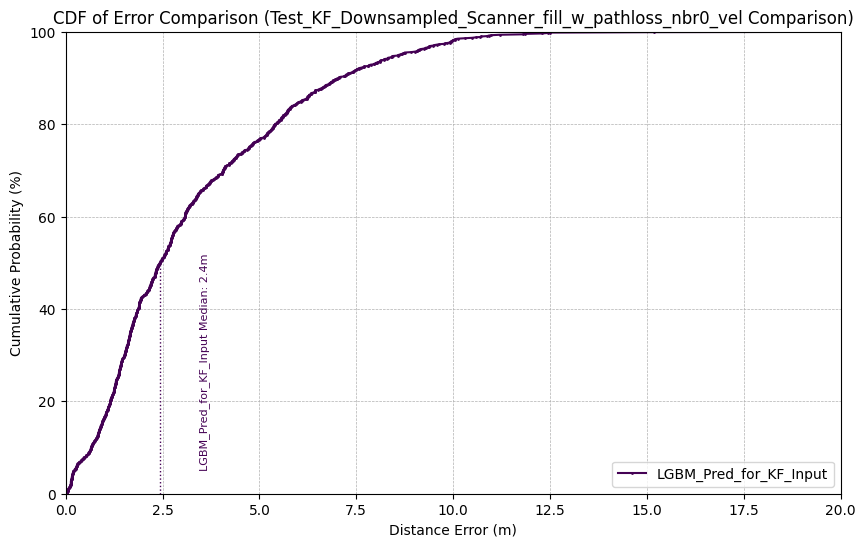

Kolom plot hilang. Butuh: ['true_lat', 'true_lon', 'pred_lat', 'pred_lon', 'kf_pred_lat', 'kf_pred_lon']


In [3]:
print(f"\n[Langkah 7/7] Menampilkan hasil evaluasi dan plot akhir...")
errors_for_cdf_comparison = {}
# Error LGBM mentah (sebelum KF, tapi pada data yang akan di-input ke KF jika ada)
errors_lgbm_for_kf_input = []
if not kf_input_df_resampled.empty:
    for i in range(len(kf_input_df_resampled)):
        row = kf_input_df_resampled.iloc[i]
        dist_lgbm = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
        if not pd.isna(dist_lgbm): errors_lgbm_for_kf_input.append(dist_lgbm)
    if errors_lgbm_for_kf_input:
        errors_for_cdf_comparison['LGBM_Pred_for_KF_Input'] = np.array(errors_lgbm_for_kf_input)

if len(errors_kf_final) > 0:
    errors_for_cdf_comparison[f'LGBM_plus_KF_{KF_MOTION_MODEL}'] = errors_kf_final

if errors_for_cdf_comparison:
    COMPARISON_CDF_PLOT_PATH = os.path.join(RESULTS_DIR_TESTING, f'{TEST_MODEL_PREFIX}_cdf_comparison.png')
    plot_cdf_from_distances(errors_for_cdf_comparison, f"{TEST_MODEL_PREFIX} Comparison", COMPARISON_CDF_PLOT_PATH)

if not results_df_with_kf.empty:
    plot_idx_start_map = 15
    plot_idx_end_map = len(results_df_with_kf)-10
    map_plot_title = f"{TEST_MODEL_PREFIX} (Subset"
    if TEST_SUBSET_FILTER_CONDITIONS: map_plot_title += f" - Filter: {' AND '.join(TEST_SUBSET_FILTER_CONDITIONS)}"
    elif TEST_SUBSET_START_INDEX is not None:
        try:
            first_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[0]].name if not df_test_subset_active.empty else TEST_SUBSET_START_INDEX
            last_original_idx = df_test_full_clean.iloc[df_test_subset_active.index[-1]].name if not df_test_subset_active.empty else TEST_SUBSET_END_INDEX -1
            map_plot_title += f" - Idx Global Asli: {first_original_idx}-{last_original_idx}"
        except: map_plot_title += f" - Idx Subset: {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}"
    map_plot_title += ")"
    
    plot_predictions_on_map_with_kf(
        results_df_with_kf, plot_idx_start_map, plot_idx_end_map,
        kf_lat_col='kf_pred_lat', kf_lon_col='kf_pred_lon', title_suffix=map_plot_title
    )
else: print("Tidak ada hasil untuk diplot pada peta perbandingan KF.")